Import Library & Konfigurasi

In [276]:
import cv2
import numpy as np
import pytesseract
import re
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [277]:
#Fungsi Perhitungan CER (Character Error Rate)
def calculate_cer(reference: str, hypothesis: str) -> float:
    n = len(reference)
    if n == 0:
        return 0.0 if len(hypothesis) == 0 else 100.0
    
    dp = [[0] * (len(hypothesis) + 1) for _ in range(len(reference) + 1)]
    for i in range(len(reference) + 1):
        dp[i][0] = i
    for j in range(len(hypothesis) + 1):
        dp[0][j] = j
        
    for i in range(1, len(reference) + 1):
        for j in range(1, len(hypothesis) + 1):
            if reference[i - 1] == hypothesis[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(
                    dp[i - 1][j],     # Deletion
                    dp[i][j - 1],     # Insertion
                    dp[i - 1][j - 1]  # Substitution
                )
                
    return (dp[len(reference)][len(hypothesis)] / n) * 100

Membaca Gambar & Grayscale Conversion

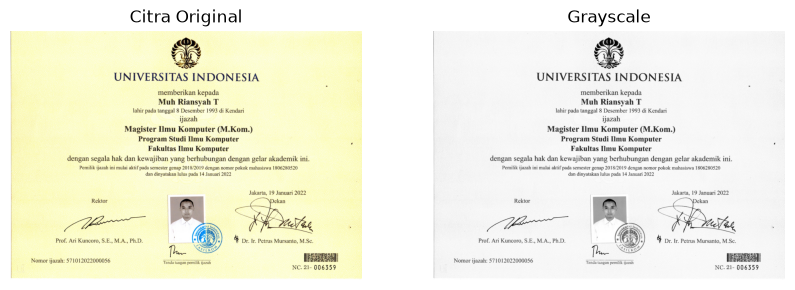

In [278]:
# 1. Load Citra Ijazah
image_path = "01_HighQuality_Enhanced.jpg"
ground_truth_nomor = "571012022000056"
img = cv2.imread(image_path)

if img is None:
    print("Error: Gambar tidak ditemukan!")
else:
    # 2. Grayscale Conversion
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Visualisasi
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("Citra Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Grayscale")
    plt.imshow(gray, cmap='gray')
    plt.axis('off')
    plt.show()

Image Enhancement (CLAHE)

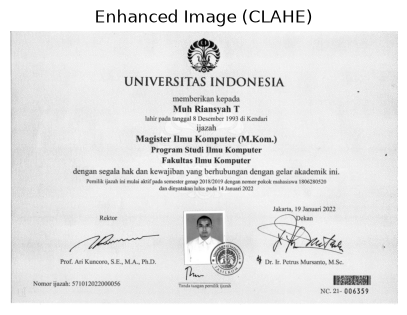

In [279]:
# 3. CLAHE Enhancement
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_img = clahe.apply(gray)

plt.figure(figsize=(5, 5))
plt.title("Enhanced Image (CLAHE)")
plt.imshow(enhanced_img, cmap='gray')
plt.axis('off')
plt.show()

Crop Region of Interest (ROI)

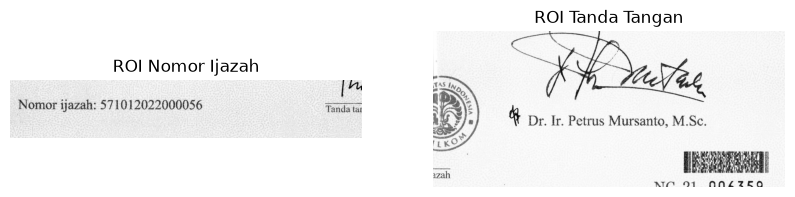

In [280]:
h, w = gray.shape

# ROI 1: Area Nomor Ijazah
roi_nomor = enhanced_img[int(h * 0.88):int(h * 0.98), int(w * 0.05):int(w * 0.48)]

# ROI 2: Area Tanda Tangan
roi_ttd = gray[int(h * 0.70):int(h * 0.95), int(w * 0.55):int(w * 0.95)]

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.title("ROI Nomor Ijazah")
plt.imshow(roi_nomor, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("ROI Tanda Tangan")
plt.imshow(roi_ttd, cmap='gray')
plt.axis('off')
plt.show()

Jalur 1 - Area Nomor (Enhancement + OCR)

Hasil Ekstraksi OCR: WM
N571012022000056 T


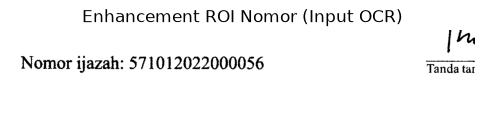

In [281]:
# Enhancement Khusus OCR
roi_nomor_blur = cv2.GaussianBlur(roi_nomor, (3, 3), 0)
_, roi_nomor_thresh = cv2.threshold(roi_nomor_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# OCR Processing
custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-'
ocr_result = pytesseract.image_to_string(roi_nomor_thresh, config=custom_config)

# Pattern Matching (Regex)
pattern = r'(DN-\d{7,9}|[A-Z]{2}-\d{7,9})'
match = re.search(pattern, ocr_result)
nomor_ijazah = match.group(0) if match else ocr_result.strip()

# Perhitungan CER
nilai_cer = calculate_cer(ground_truth_nomor, nomor_ijazah if nomor_ijazah != "NOT DETECTED" else "")

print(f"Hasil Ekstraksi OCR: {nomor_ijazah}")

plt.figure(figsize=(6, 2))
plt.title("Enhancement ROI Nomor (Input OCR)")
plt.imshow(roi_nomor_thresh, cmap='gray')
plt.axis('off')
plt.show()

Jalur 2 - Area Tanda Tangan (Thresholding + Morphology + Signature Detection)

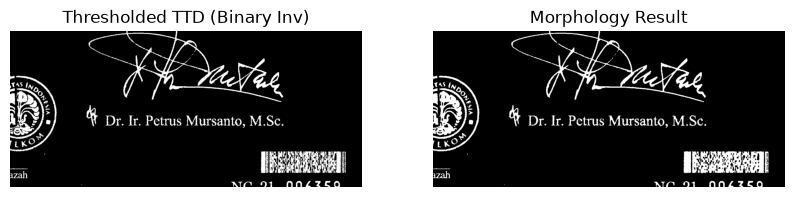

In [282]:
# Thresholding (Inversi)
_, ttd_thresh = cv2.threshold(roi_ttd, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Morphology (Closing)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
ttd_morph = cv2.morphologyEx(ttd_thresh, cv2.MORPH_CLOSE, kernel)

# Connected Component Analysis (CCA)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(ttd_morph)

has_signature = False
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area > 1500:
        has_signature = True
        break
\
status_ttd = "PRESENT" if has_signature else "NOT PRESENT"

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.title("Thresholded TTD (Binary Inv)")
plt.imshow(ttd_thresh, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Morphology Result")
plt.imshow(ttd_morph, cmap='gray')
plt.axis('off')
plt.show()

Output Hasil Verifikasi Final

In [283]:
print("=" * 60)
print("       HASIL VERIFIKASI IJAZAH     ")
print("=" * 60)
print(f"Input        : {image_path}")
print("===    Output    ===")
print(f"Nomor Ijazah : {nomor_ijazah}")
print(f"Tanda Tangan : {status_ttd}")
print(f"Nilai CER    : {nilai_cer:.2f}%")
print("=" * 60)

       HASIL VERIFIKASI IJAZAH     
Input        : 01_HighQuality_Enhanced.jpg
===    Output    ===
Nomor Ijazah : WM
N571012022000056 T
Tanda Tangan : PRESENT
Nilai CER    : 40.00%
